In [3]:
#Read all data
import csv
import pandas as pd
dataset=pd.read_csv('/content/drive/MyDrive/Project 581/FaceFeatures.csv')
dataset.head()

,1,2,3,4,5,6,7,8,9,10,...,248,249,250,251,252,253,254,255,256,Label
0,513,81,132,103,89,57,175,37,414,1661,...,358,39,157,56,125,104,93,60,568,1
1,496,79,111,117,104,57,171,31,427,1671,...,358,44,159,57,107,105,96,56,538,1
2,478,80,123,110,101,55,159,40,411,1542,...,366,39,143,62,102,86,107,65,429,1
3,546,81,132,98,94,63,159,36,384,1416,...,402,35,148,70,101,94,96,63,566,1
4,494,99,142,114,115,65,154,44,400,1717,...,365,36,153,63,98,104,95,62,626,1


In [2]:
dataset.shape

(10320, 257)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#replace the user ID by class name and count the number of sample in each class
dataset['Label'] = pd.factorize(dataset['Label'])[0]
dataset.groupby(['Label'])['Label'].count()

Label
0     120
1     120
2     120
3     120
4     120
     ... 
81    120
82    120
83    120
84    120
85    120
Name: Label, Length: 86, dtype: int64

In [5]:
#seperate the profile in two groups: (i) Training profile (0-42), and (ii) auxiliary profile (43-86)
totalUser= len(pd.unique(dataset['Label']))
trainingData = dataset[dataset['Label'] < int(totalUser/2)]
auxilaryData = dataset[dataset['Label'] >= int(totalUser/2)]
print("Total user in training dataset:", len(pd.unique(trainingData['Label'])))
print("Total user in auxiliary dataset:", len(pd.unique(auxilaryData['Label'])))

Total user in training dataset: 43
Total user in auxiliary dataset: 43


In [6]:
#Prepare the traning data for training and testing the model
import tensorflow
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

Xtrain, Xtest= train_test_split(trainingData, test_size=0.2, random_state=22)
Xtrain.groupby(['Label'])['Label'].count()

Label
0      97
1      95
2      94
3     100
4     100
5      92
6      96
7      95
8     100
9      99
10     96
11     94
12     99
13     95
14     98
15     97
16     99
17     94
18     94
19     96
20    102
21     97
22     93
23     95
24     99
25     93
26     96
27    100
28     95
29     95
30     98
31     90
32     97
33     96
34     92
35     87
36     97
37     96
38     99
39     98
40     99
41     93
42     91
Name: Label, dtype: int64

In [20]:
values = ', '.join([f"'RPF{i}'" for i in range(1, 246)])
print(values)


'RPF1', 'RPF2', 'RPF3', 'RPF4', 'RPF5', 'RPF6', 'RPF7', 'RPF8', 'RPF9', 'RPF10', 'RPF11', 'RPF12', 'RPF13', 'RPF14', 'RPF15', 'RPF16', 'RPF17', 'RPF18', 'RPF19', 'RPF20', 'RPF21', 'RPF22', 'RPF23', 'RPF24', 'RPF25', 'RPF26', 'RPF27', 'RPF28', 'RPF29', 'RPF30', 'RPF31', 'RPF32', 'RPF33', 'RPF34', 'RPF35', 'RPF36', 'RPF37', 'RPF38', 'RPF39', 'RPF40', 'RPF41', 'RPF42', 'RPF43', 'RPF44', 'RPF45', 'RPF46', 'RPF47', 'RPF48', 'RPF49', 'RPF50', 'RPF51', 'RPF52', 'RPF53', 'RPF54', 'RPF55', 'RPF56', 'RPF57', 'RPF58', 'RPF59', 'RPF60', 'RPF61', 'RPF62', 'RPF63', 'RPF64', 'RPF65', 'RPF66', 'RPF67', 'RPF68', 'RPF69', 'RPF70', 'RPF71', 'RPF72', 'RPF73', 'RPF74', 'RPF75', 'RPF76', 'RPF77', 'RPF78', 'RPF79', 'RPF80', 'RPF81', 'RPF82', 'RPF83', 'RPF84', 'RPF85', 'RPF86', 'RPF87', 'RPF88', 'RPF89', 'RPF90', 'RPF91', 'RPF92', 'RPF93', 'RPF94', 'RPF95', 'RPF96', 'RPF97', 'RPF98', 'RPF99', 'RPF100', 'RPF101', 'RPF102', 'RPF103', 'RPF104', 'RPF105', 'RPF106', 'RPF107', 'RPF108', 'RPF109', 'RPF110', 'RPF111'

In [7]:
import numpy as np
import pandas as pd
from sklearn.random_projection import SparseRandomProjection

column1=['RPF1', 'RPF2', 'RPF3', 'RPF4', 'RPF5', 'RPF6', 'RPF7', 'RPF8', 'RPF9', 'RPF10', 'RPF11', 'RPF12', 'RPF13', 'RPF14', 'RPF15', 'RPF16', 'RPF17', 'RPF18',
         'RPF19', 'RPF20', 'RPF21', 'RPF22', 'RPF23', 'RPF24', 'RPF25', 'RPF26', 'RPF27', 'RPF28', 'RPF29', 'RPF30', 'RPF31', 'RPF32', 'RPF33', 'RPF34', 'RPF35',
         'RPF36', 'RPF37', 'RPF38', 'RPF39', 'RPF40', 'RPF41', 'RPF42', 'RPF43', 'RPF44', 'RPF45', 'RPF46', 'RPF47', 'RPF48', 'RPF49', 'RPF50', 'RPF51', 'RPF52',
         'RPF53', 'RPF54', 'RPF55', 'RPF56', 'RPF57', 'RPF58', 'RPF59', 'RPF60', 'RPF61', 'RPF62', 'RPF63', 'RPF64', 'RPF65', 'RPF66', 'RPF67', 'RPF68', 'RPF69',
         'RPF70', 'RPF71', 'RPF72', 'RPF73', 'RPF74', 'RPF75', 'RPF76', 'RPF77', 'RPF78', 'RPF79', 'RPF80', 'RPF81', 'RPF82', 'RPF83', 'RPF84', 'RPF85', 'RPF86',
         'RPF87', 'RPF88', 'RPF89', 'RPF90', 'RPF91', 'RPF92', 'RPF93', 'RPF94', 'RPF95', 'RPF96', 'RPF97', 'RPF98', 'RPF99', 'RPF100', 'RPF101', 'RPF102',
         'RPF103', 'RPF104', 'RPF105', 'RPF106', 'RPF107', 'RPF108', 'RPF109', 'RPF110', 'RPF111', 'RPF112', 'RPF113', 'RPF114', 'RPF115', 'RPF116', 'RPF117',
         'RPF118', 'RPF119', 'RPF120', 'RPF121', 'RPF122', 'RPF123', 'RPF124', 'RPF125', 'RPF126', 'RPF127', 'RPF128', 'RPF129', 'RPF130', 'RPF131', 'RPF132',
         'RPF133', 'RPF134', 'RPF135', 'RPF136', 'RPF137', 'RPF138', 'RPF139', 'RPF140', 'RPF141', 'RPF142', 'RPF143', 'RPF144', 'RPF145', 'RPF146', 'RPF147',
         'RPF148', 'RPF149', 'RPF150', 'RPF151', 'RPF152', 'RPF153', 'RPF154', 'RPF155', 'RPF156', 'RPF157', 'RPF158', 'RPF159', 'RPF160', 'RPF161', 'RPF162',
         'RPF163', 'RPF164', 'RPF165', 'RPF166', 'RPF167', 'RPF168', 'RPF169', 'RPF170', 'RPF171', 'RPF172', 'RPF173', 'RPF174', 'RPF175', 'RPF176', 'RPF177',
         'RPF178', 'RPF179', 'RPF180', 'RPF181', 'RPF182', 'RPF183', 'RPF184', 'RPF185', 'RPF186', 'RPF187', 'RPF188', 'RPF189', 'RPF190', 'RPF191', 'RPF192',
         'RPF193', 'RPF194', 'RPF195', 'RPF196', 'RPF197', 'RPF198', 'RPF199', 'RPF200', 'RPF201', 'RPF202', 'RPF203', 'RPF204', 'RPF205', 'RPF206', 'RPF207',
         'RPF208', 'RPF209', 'RPF210', 'RPF211', 'RPF212', 'RPF213', 'RPF214', 'RPF215', 'RPF216', 'RPF217', 'RPF218', 'RPF219', 'RPF220', 'RPF221', 'RPF222',
         'RPF223', 'RPF224', 'RPF225', 'RPF226', 'RPF227', 'RPF228', 'RPF229', 'RPF230', 'RPF231', 'RPF232', 'RPF233', 'RPF234', 'RPF235', 'RPF236', 'RPF237',
         'RPF238', 'RPF239', 'RPF240', 'RPF241', 'RPF242', 'RPF243', 'RPF244', 'RPF245', 'RPF246','Label']
column2=column1=['RPF1', 'RPF2', 'RPF3', 'RPF4', 'RPF5', 'RPF6', 'RPF7', 'RPF8', 'RPF9', 'RPF10', 'RPF11', 'RPF12', 'RPF13', 'RPF14', 'RPF15', 'RPF16', 'RPF17', 'RPF18',
         'RPF19', 'RPF20', 'RPF21', 'RPF22', 'RPF23', 'RPF24', 'RPF25', 'RPF26', 'RPF27', 'RPF28', 'RPF29', 'RPF30', 'RPF31', 'RPF32', 'RPF33', 'RPF34', 'RPF35',
         'RPF36', 'RPF37', 'RPF38', 'RPF39', 'RPF40', 'RPF41', 'RPF42', 'RPF43', 'RPF44', 'RPF45', 'RPF46', 'RPF47', 'RPF48', 'RPF49', 'RPF50', 'RPF51', 'RPF52',
         'RPF53', 'RPF54', 'RPF55', 'RPF56', 'RPF57', 'RPF58', 'RPF59', 'RPF60', 'RPF61', 'RPF62', 'RPF63', 'RPF64', 'RPF65', 'RPF66', 'RPF67', 'RPF68', 'RPF69',
         'RPF70', 'RPF71', 'RPF72', 'RPF73', 'RPF74', 'RPF75', 'RPF76', 'RPF77', 'RPF78', 'RPF79', 'RPF80', 'RPF81', 'RPF82', 'RPF83', 'RPF84', 'RPF85', 'RPF86',
         'RPF87', 'RPF88', 'RPF89', 'RPF90', 'RPF91', 'RPF92', 'RPF93', 'RPF94', 'RPF95', 'RPF96', 'RPF97', 'RPF98', 'RPF99', 'RPF100', 'RPF101', 'RPF102',
         'RPF103', 'RPF104', 'RPF105', 'RPF106', 'RPF107', 'RPF108', 'RPF109', 'RPF110', 'RPF111', 'RPF112', 'RPF113', 'RPF114', 'RPF115', 'RPF116', 'RPF117',
         'RPF118', 'RPF119', 'RPF120', 'RPF121', 'RPF122', 'RPF123', 'RPF124', 'RPF125', 'RPF126', 'RPF127', 'RPF128', 'RPF129', 'RPF130', 'RPF131', 'RPF132',
         'RPF133', 'RPF134', 'RPF135', 'RPF136', 'RPF137', 'RPF138', 'RPF139', 'RPF140', 'RPF141', 'RPF142', 'RPF143', 'RPF144', 'RPF145', 'RPF146', 'RPF147',
         'RPF148', 'RPF149', 'RPF150', 'RPF151', 'RPF152', 'RPF153', 'RPF154', 'RPF155', 'RPF156', 'RPF157', 'RPF158', 'RPF159', 'RPF160', 'RPF161', 'RPF162',
         'RPF163', 'RPF164', 'RPF165', 'RPF166', 'RPF167', 'RPF168', 'RPF169', 'RPF170', 'RPF171', 'RPF172', 'RPF173', 'RPF174', 'RPF175', 'RPF176', 'RPF177',
         'RPF178', 'RPF179', 'RPF180', 'RPF181', 'RPF182', 'RPF183', 'RPF184', 'RPF185', 'RPF186', 'RPF187', 'RPF188', 'RPF189', 'RPF190', 'RPF191', 'RPF192',
         'RPF193', 'RPF194', 'RPF195', 'RPF196', 'RPF197', 'RPF198', 'RPF199', 'RPF200', 'RPF201', 'RPF202', 'RPF203', 'RPF204', 'RPF205', 'RPF206', 'RPF207',
         'RPF208', 'RPF209', 'RPF210', 'RPF211', 'RPF212', 'RPF213', 'RPF214', 'RPF215', 'RPF216', 'RPF217', 'RPF218', 'RPF219', 'RPF220', 'RPF221', 'RPF222',
         'RPF223', 'RPF224', 'RPF225', 'RPF226', 'RPF227', 'RPF228', 'RPF229', 'RPF230', 'RPF231', 'RPF232', 'RPF233', 'RPF234', 'RPF235', 'RPF236', 'RPF237',
         'RPF238', 'RPF239', 'RPF240', 'RPF241', 'RPF242', 'RPF243', 'RPF244', 'RPF245', 'RPF246']

trainDatasetRP = pd.DataFrame(columns=column1)

# Assuming Xtrain is defined before this code snippet

for seed in range(0, 43):
    rng = np.random.RandomState(seed)
    X = Xtrain[Xtrain['Label'] == seed]
    transformer = SparseRandomProjection(n_components=246, random_state=rng)
    Xdata = X.drop(columns=['Label'])
    XRP = pd.DataFrame(transformer.fit_transform(Xdata), columns=column2)
    XRP['Label'] = seed
    trainDatasetRP = trainDatasetRP.append(XRP, ignore_index=True)

print(Xtrain.shape)
print(trainDatasetRP.shape)


<ipython-input-7-9c6318fc16cb>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  trainDatasetRP = trainDatasetRP.append(XRP, ignore_index=True)
<ipython-input-7-9c6318fc16cb>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  trainDatasetRP = trainDatasetRP.append(XRP, ignore_index=True)
<ipython-input-7-9c6318fc16cb>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  trainDatasetRP = trainDatasetRP.append(XRP, ignore_index=True)
<ipython-input-7-9c6318fc16cb>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  trainDatasetRP = trainDatasetRP.append(XRP, ignore_index=True)
<ipython-input-7-9c6318fc16cb>:49: FutureWarning: The frame.append m

(4128, 257)
(4128, 247)


<ipython-input-7-9c6318fc16cb>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  trainDatasetRP = trainDatasetRP.append(XRP, ignore_index=True)
<ipython-input-7-9c6318fc16cb>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  trainDatasetRP = trainDatasetRP.append(XRP, ignore_index=True)
<ipython-input-7-9c6318fc16cb>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  trainDatasetRP = trainDatasetRP.append(XRP, ignore_index=True)
<ipython-input-7-9c6318fc16cb>:49: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  trainDatasetRP = trainDatasetRP.append(XRP, ignore_index=True)
<ipython-input-7-9c6318fc16cb>:49: FutureWarning: The frame.append m

In [8]:

print(Xtrain.shape)
print(trainDatasetRP.shape)


(4128, 257)
(4128, 247)


In [9]:
#random project the test data
import numpy as np
from sklearn.random_projection import SparseRandomProjection
column1=['RPF1', 'RPF2', 'RPF3', 'RPF4', 'RPF5', 'RPF6', 'RPF7', 'RPF8', 'RPF9', 'RPF10', 'RPF11', 'RPF12', 'RPF13', 'RPF14', 'RPF15', 'RPF16', 'RPF17', 'RPF18',
         'RPF19', 'RPF20', 'RPF21', 'RPF22', 'RPF23', 'RPF24', 'RPF25', 'RPF26', 'RPF27', 'RPF28', 'RPF29', 'RPF30', 'RPF31', 'RPF32', 'RPF33', 'RPF34', 'RPF35',
         'RPF36', 'RPF37', 'RPF38', 'RPF39', 'RPF40', 'RPF41', 'RPF42', 'RPF43', 'RPF44', 'RPF45', 'RPF46', 'RPF47', 'RPF48', 'RPF49', 'RPF50', 'RPF51', 'RPF52',
         'RPF53', 'RPF54', 'RPF55', 'RPF56', 'RPF57', 'RPF58', 'RPF59', 'RPF60', 'RPF61', 'RPF62', 'RPF63', 'RPF64', 'RPF65', 'RPF66', 'RPF67', 'RPF68', 'RPF69',
         'RPF70', 'RPF71', 'RPF72', 'RPF73', 'RPF74', 'RPF75', 'RPF76', 'RPF77', 'RPF78', 'RPF79', 'RPF80', 'RPF81', 'RPF82', 'RPF83', 'RPF84', 'RPF85', 'RPF86',
         'RPF87', 'RPF88', 'RPF89', 'RPF90', 'RPF91', 'RPF92', 'RPF93', 'RPF94', 'RPF95', 'RPF96', 'RPF97', 'RPF98', 'RPF99', 'RPF100', 'RPF101', 'RPF102',
         'RPF103', 'RPF104', 'RPF105', 'RPF106', 'RPF107', 'RPF108', 'RPF109', 'RPF110', 'RPF111', 'RPF112', 'RPF113', 'RPF114', 'RPF115', 'RPF116', 'RPF117',
         'RPF118', 'RPF119', 'RPF120', 'RPF121', 'RPF122', 'RPF123', 'RPF124', 'RPF125', 'RPF126', 'RPF127', 'RPF128', 'RPF129', 'RPF130', 'RPF131', 'RPF132',
         'RPF133', 'RPF134', 'RPF135', 'RPF136', 'RPF137', 'RPF138', 'RPF139', 'RPF140', 'RPF141', 'RPF142', 'RPF143', 'RPF144', 'RPF145', 'RPF146', 'RPF147',
         'RPF148', 'RPF149', 'RPF150', 'RPF151', 'RPF152', 'RPF153', 'RPF154', 'RPF155', 'RPF156', 'RPF157', 'RPF158', 'RPF159', 'RPF160', 'RPF161', 'RPF162',
         'RPF163', 'RPF164', 'RPF165', 'RPF166', 'RPF167', 'RPF168', 'RPF169', 'RPF170', 'RPF171', 'RPF172', 'RPF173', 'RPF174', 'RPF175', 'RPF176', 'RPF177',
         'RPF178', 'RPF179', 'RPF180', 'RPF181', 'RPF182', 'RPF183', 'RPF184', 'RPF185', 'RPF186', 'RPF187', 'RPF188', 'RPF189', 'RPF190', 'RPF191', 'RPF192',
         'RPF193', 'RPF194', 'RPF195', 'RPF196', 'RPF197', 'RPF198', 'RPF199', 'RPF200', 'RPF201', 'RPF202', 'RPF203', 'RPF204', 'RPF205', 'RPF206', 'RPF207',
         'RPF208', 'RPF209', 'RPF210', 'RPF211', 'RPF212', 'RPF213', 'RPF214', 'RPF215', 'RPF216', 'RPF217', 'RPF218', 'RPF219', 'RPF220', 'RPF221', 'RPF222',
         'RPF223', 'RPF224', 'RPF225', 'RPF226', 'RPF227', 'RPF228', 'RPF229', 'RPF230', 'RPF231', 'RPF232', 'RPF233', 'RPF234', 'RPF235', 'RPF236', 'RPF237',
         'RPF238', 'RPF239', 'RPF240', 'RPF241', 'RPF242', 'RPF243', 'RPF244', 'RPF245', 'RPF246','Label']
column2=column1=['RPF1', 'RPF2', 'RPF3', 'RPF4', 'RPF5', 'RPF6', 'RPF7', 'RPF8', 'RPF9', 'RPF10', 'RPF11', 'RPF12', 'RPF13', 'RPF14', 'RPF15', 'RPF16', 'RPF17', 'RPF18',
         'RPF19', 'RPF20', 'RPF21', 'RPF22', 'RPF23', 'RPF24', 'RPF25', 'RPF26', 'RPF27', 'RPF28', 'RPF29', 'RPF30', 'RPF31', 'RPF32', 'RPF33', 'RPF34', 'RPF35',
         'RPF36', 'RPF37', 'RPF38', 'RPF39', 'RPF40', 'RPF41', 'RPF42', 'RPF43', 'RPF44', 'RPF45', 'RPF46', 'RPF47', 'RPF48', 'RPF49', 'RPF50', 'RPF51', 'RPF52',
         'RPF53', 'RPF54', 'RPF55', 'RPF56', 'RPF57', 'RPF58', 'RPF59', 'RPF60', 'RPF61', 'RPF62', 'RPF63', 'RPF64', 'RPF65', 'RPF66', 'RPF67', 'RPF68', 'RPF69',
         'RPF70', 'RPF71', 'RPF72', 'RPF73', 'RPF74', 'RPF75', 'RPF76', 'RPF77', 'RPF78', 'RPF79', 'RPF80', 'RPF81', 'RPF82', 'RPF83', 'RPF84', 'RPF85', 'RPF86',
         'RPF87', 'RPF88', 'RPF89', 'RPF90', 'RPF91', 'RPF92', 'RPF93', 'RPF94', 'RPF95', 'RPF96', 'RPF97', 'RPF98', 'RPF99', 'RPF100', 'RPF101', 'RPF102',
         'RPF103', 'RPF104', 'RPF105', 'RPF106', 'RPF107', 'RPF108', 'RPF109', 'RPF110', 'RPF111', 'RPF112', 'RPF113', 'RPF114', 'RPF115', 'RPF116', 'RPF117',
         'RPF118', 'RPF119', 'RPF120', 'RPF121', 'RPF122', 'RPF123', 'RPF124', 'RPF125', 'RPF126', 'RPF127', 'RPF128', 'RPF129', 'RPF130', 'RPF131', 'RPF132',
         'RPF133', 'RPF134', 'RPF135', 'RPF136', 'RPF137', 'RPF138', 'RPF139', 'RPF140', 'RPF141', 'RPF142', 'RPF143', 'RPF144', 'RPF145', 'RPF146', 'RPF147',
         'RPF148', 'RPF149', 'RPF150', 'RPF151', 'RPF152', 'RPF153', 'RPF154', 'RPF155', 'RPF156', 'RPF157', 'RPF158', 'RPF159', 'RPF160', 'RPF161', 'RPF162',
         'RPF163', 'RPF164', 'RPF165', 'RPF166', 'RPF167', 'RPF168', 'RPF169', 'RPF170', 'RPF171', 'RPF172', 'RPF173', 'RPF174', 'RPF175', 'RPF176', 'RPF177',
         'RPF178', 'RPF179', 'RPF180', 'RPF181', 'RPF182', 'RPF183', 'RPF184', 'RPF185', 'RPF186', 'RPF187', 'RPF188', 'RPF189', 'RPF190', 'RPF191', 'RPF192',
         'RPF193', 'RPF194', 'RPF195', 'RPF196', 'RPF197', 'RPF198', 'RPF199', 'RPF200', 'RPF201', 'RPF202', 'RPF203', 'RPF204', 'RPF205', 'RPF206', 'RPF207',
         'RPF208', 'RPF209', 'RPF210', 'RPF211', 'RPF212', 'RPF213', 'RPF214', 'RPF215', 'RPF216', 'RPF217', 'RPF218', 'RPF219', 'RPF220', 'RPF221', 'RPF222',
         'RPF223', 'RPF224', 'RPF225', 'RPF226', 'RPF227', 'RPF228', 'RPF229', 'RPF230', 'RPF231', 'RPF232', 'RPF233', 'RPF234', 'RPF235', 'RPF236', 'RPF237',
         'RPF238', 'RPF239', 'RPF240', 'RPF241', 'RPF242', 'RPF243', 'RPF244', 'RPF245', 'RPF246']
testDatasetRP = pd.DataFrame(columns=column1)

for seed in range(0,43):
    rng = np.random.RandomState(seed+1)
    X = Xtest[Xtest['Label']==seed]
    transformer = SparseRandomProjection(n_components=246, random_state=rng)
    Xdata=X.drop(columns=['Label'])
    XRP = pd.DataFrame(transformer.fit_transform(Xdata),columns=column2)
    XRP['Label']=seed
    testDatasetRP = pd.concat([testDatasetRP, XRP], ignore_index=True)
    #print("Shape of Actual data:",Xdata.shape)
    #print("Shape of Randome Matrix:", transformer.components_.shape[1],transformer.components_.shape[0])
    #print("Shape of Projected data:", X_new.shape)
print(Xtest.shape)
print(testDatasetRP.shape)

(1032, 257)
(1032, 247)


In [10]:
#Prepare the traning data for training and testing the model
import tensorflow
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

X=trainDatasetRP.drop(columns=['Label'])
y=trainDatasetRP['Label']

Xtrain, Xval, ytrain, yval = train_test_split(X, y, test_size=0.2, random_state=22)

Xtest=testDatasetRP.drop(columns=['Label'])
ytest=testDatasetRP['Label']

ytrain = to_categorical(ytrain)
yval = to_categorical(yval)
ytest = to_categorical(ytest)

In [11]:
print(Xtrain.shape)
print(ytrain.shape)
print(Xval.shape)
print(yval.shape)
print(Xtest.shape)
print(ytest.shape)

(3302, 246)
(3302, 43)
(826, 246)
(826, 43)
(1032, 246)
(1032, 43)


In [12]:
# import all necessary package for a neural network
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#matplotlib inlineimport keras
from keras.layers import Dense, Dropout, Input,Activation,Dropout, Flatten
from keras.models import Model,Sequential
from keras.datasets import mnist
#from tqdm import tqdm
#from keras.layers.advanced_activations import LeakyReLU
from keras.layers import BatchNormalization
from keras.optimizers import Adam
#import torch.nn.functional as F

In [13]:
#define optimizers for neural network
from keras.optimizers import SGD, RMSprop, Adam
def adam_optimizer():
    return Adam(lr=0.0002, beta_1=0.5)

def RMSprop_optimizer():
    return RMSprop(lr=0.001, rho=0.9)

In [16]:
def create_classifierRP(release=False, totalClass=10):
    classifier = Sequential()
    classifier.add(Dense(64, input_dim=246))
    classifier.add(BatchNormalization())
    classifier.add(Activation('relu'))
    classifier.add(Dropout(0.2))

    classifier.add(Dense(128))
    classifier.add(BatchNormalization())
    classifier.add(Activation('relu'))
    classifier.add(Dropout(0.2))

    classifier.add(Dense(256))
    classifier.add(BatchNormalization())
    classifier.add(Activation('relu'))
    classifier.add(Dropout(0.2))

    classifier.add(Dense(128))
    classifier.add(BatchNormalization())
    classifier.add(Activation('relu'))
    classifier.add(Dropout(0.2))

    classifier.add(Dense(totalClass, activation='softmax'))


    classifier.compile(loss='categorical_crossentropy', optimizer=RMSprop_optimizer(), metrics=['accuracy'])
    return classifier

Clasf=create_classifierRP()
Clasf.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_10 (Dense)            (None, 64)                15808     
                                                                 
 batch_normalization_8 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                                 
 activation_8 (Activation)   (None, 64)                0         
                                                                 
 dropout_8 (Dropout)         (None, 64)                0         
                                                                 
 dense_11 (Dense)            (None, 128)               8320      
                                                                 
 batch_normalization_9 (Batc  (None, 128)              512       
 hNormalization)                                      

/usr/local/lib/python3.10/dist-packages/keras/optimizers/legacy/rmsprop.py:143: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [17]:
#Train the classifier seperately for black-box attack
import keras

from keras.datasets import mnist
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, UpSampling2D
from keras.optimizers import SGD, RMSprop, Adam
from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc', patience=5, verbose=1, factor=0.5,min_lr=0.0001)
# callbacks_list = [learning_rate_reduction]

Classfier2= create_classifierRP(True,43)

#------Comment will start from here
lossc='categorical_crossentropy'
optimizerc=RMSprop(lr=0.001, rho=0.9)
Classfier2.compile(loss=lossc, optimizer=optimizerc,metrics=['accuracy'])
#------Comments will end from here
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
historyc2 = Classfier2.fit(Xtrain, ytrain, batch_size=64, epochs=50, validation_data=(Xval, yval), verbose=1, callbacks=[early_stopping])

Epoch 1/50
52/52 [==============================] - 5s 13ms/step - loss: 1.6790 - accuracy: 0.7123 - val_loss: 1.1056 - val_accuracy: 0.9988
Epoch 2/50
52/52 [==============================] - 0s 8ms/step - loss: 0.3845 - accuracy: 0.9779 - val_loss: 0.2375 - val_accuracy: 1.0000
Epoch 3/50
52/52 [==============================] - 0s 8ms/step - loss: 0.1421 - accuracy: 0.9933 - val_loss: 0.0321 - val_accuracy: 1.0000
Epoch 4/50
52/52 [==============================] - 1s 11ms/step - loss: 0.0636 - accuracy: 0.9958 - val_loss: 0.0048 - val_accuracy: 1.0000
Epoch 5/50
52/52 [==============================] - 1s 11ms/step - loss: 0.0379 - accuracy: 0.9973 - val_loss: 8.6453e-04 - val_accuracy: 1.0000
Epoch 6/50
52/52 [==============================] - 1s 11ms/step - loss: 0.0233 - accuracy: 0.9988 - val_loss: 2.2731e-04 - val_accuracy: 1.0000
Epoch 7/50
52/52 [==============================] - 1s 11ms/step - loss: 0.0215 - accuracy: 0.9967 - val_loss: 7.7089e-05 - val_accuracy: 1.0000
Epo

Text(0.5, 0, 'epochs')

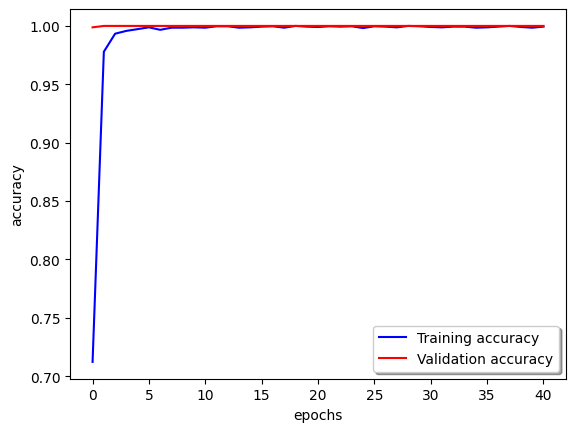

In [18]:
# Plot the classifier loss and accuracy curves for training and validation data
import matplotlib.pyplot as plt
plt.plot(historyc2.history['accuracy'], color='b', label="Training accuracy")
plt.plot(historyc2.history['val_accuracy'], color='r',label="Validation accuracy")
legend = plt.legend(loc='best', shadow=True)
plt.ylabel('accuracy')
plt.xlabel('epochs')

In [19]:
#Performance of the classifier
Classfier2.compile(loss='categorical_crossentropy', optimizer=Adam(),metrics=['accuracy'])
loss, accuracy = Classfier2.evaluate(Xtest, ytest)
#print('Test score:', score)
print('Loss:', loss)
print('Accuracy:', accuracy)

33/33 [==============================] - 0s 3ms/step - loss: 25.6108 - accuracy: 0.0000e+00
Loss: 25.61075210571289
Accuracy: 0.0
